# Project 6 - The Sharpness Quest: Main Report 
Reproduces every figure and number in the report from saved files. **No cVAE is trained here.**

Required files in the same folder as this notebook:
`mnist_custom.pt`, `cvae_baseline.pt`, `cvae_baseline_history.pkl`, `cvae_disc.pt`, `cvae_disc_history.pkl`, `digit_classifier.pt`
(the classifier is trained once and saved if `digit_classifier.pt` is missing).


In [1]:
import os, pickle, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

def set_seed(s):
    torch.manual_seed(s); np.random.seed(s); random.seed(s)
set_seed(0)

required = ['mnist_custom.pt', 'cvae_baseline.pt', 'cvae_baseline_history.pkl',
            'cvae_disc.pt', 'cvae_disc_history.pkl']
missing = [f for f in required if not os.path.exists(f)]
assert not missing, f'Missing files: {missing}'
print('all required files found')


device: cuda
all required files found


## Data


In [2]:
d = torch.load('mnist_custom.pt', map_location='cpu', weights_only=False)
train_x, train_y = d['train_images'], d['train_labels']
test_x,  test_y  = d['test_images'],  d['test_labels']
print('train', tuple(train_x.shape), 'test', tuple(test_x.shape))


train (60000, 1, 20, 20) test (10000, 1, 20, 20)


## Model definitions (identical to the training notebooks)


In [3]:
# Create an encoder to encode the 1x20x20 images into a latent vector of dimension z_dim
class cEncoder(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cEncoder, self).__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        # Define the encoder layers
        self.encoder_backbone = nn.Sequential(
            # Layer 1: 1x20x20 -> 16x10x10
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 2: 16x10x10 -> 32x5x5
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 3: 32x5x5 -> 64x3x3
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Layer 4: 64x3x3 -> 256x1x1 (kernel 3 instead of 4 for the 20x20 dataset)
            nn.Conv2d(64, 256, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            # Flatten and project to z_dim
            nn.Flatten(),  # 256*1*1 = 256
        )
        self.encoder_head = nn. Sequential(
           nn.Linear(256+num_classes, 2*z_dim)
        )
         
    def forward(self, x, cond):
        # x shape: (batch_size, 1, 20, 20)        
        # TODO: Implement the encoder network to map x, cond to mu and log-var
        x = self.encoder_backbone(x)
        x = torch.cat([x, cond], dim =1)
        x = self.encoder_head(x)
        mu, logvar=torch.chunk(x, 2, dim=1)
        return mu,logvar

class cDecoder(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cDecoder, self).__init__()
        self.z_dim = z_dim
        self.num_classes = num_classes
        self.decoder_input =  nn.Sequential(
            # Project latent vector to a feature map
            nn.Linear(z_dim + num_classes, 256), 
            nn.ReLU(),
        )
        self.decoder_backbone = nn.Sequential(
            nn.Unflatten(1, (256, 1, 1)),  # Reshape to (256, 1, 1)
            # Layer 1: 256x1x1 -> 64x5x5
            nn.ConvTranspose2d(256, 64, kernel_size=5, stride=1, padding=0),
            nn.ReLU(),
            # Layer 2: 64x5x5 -> 32x10x10
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # Layer 3: 32x10x10 -> 16x20x20
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # Layer 4: 16x20x20 -> 1x20x20
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid()  # Output in [0, 1] for pixel values
        )

    def forward(self, z, cond):
        # z shape: (batch_size, z_dim)
        # cond shape: (batch_size, num_classes)
        #TODO: inplement the decoder to generate a new sample from a latent vector and condition
        x = self.decoder_input(torch.cat([z, cond], dim=1))
        x_hat = self.decoder_backbone(x)
        return x_hat

class cVAE(nn.Module):
    def __init__(self, z_dim, num_classes):
        super(cVAE, self).__init__()
        self.encoder = cEncoder(z_dim, num_classes)
        self.decoder = cDecoder(z_dim, num_classes)
        self.z_dim =  z_dim
        self.num_classes = num_classes
    
    def encode(self,x,cond):
        return self.encoder(x,cond)

    def decode(self,z,cond):
        return self.decoder(z,cond)
    
    def forward(self, x, cond):
        mu,logvar = self.encoder(x, cond)
        # TODO: implement the reparametrization trick to sample the latent z
        sigma = (0.5 *logvar).exp()
        eps = torch.randn_like(sigma)
        z = mu + sigma * eps 
        x_recon = self.decoder(z, cond)
        return x_recon,mu,logvar

## Load both trained cVAEs


In [4]:
z_dim = 7
models = {}
for name, path in [('Baseline cVAE', 'cvae_baseline.pt'), ('cVAE + discriminator', 'cvae_disc.pt')]:
    m = cVAE(z_dim, num_classes=10).to(device)
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    models[name] = m
    print('loaded', name, 'from', path)

with open('cvae_baseline_history.pkl', 'rb') as f:
    hist_base = pickle.load(f)
with open('cvae_disc_history.pkl', 'rb') as f:
    disc_file = pickle.load(f)
hist_disc = disc_file['history']
print('lambda_adv used for the discriminator model:', disc_file['lam_adv'])


loaded Baseline cVAE from cvae_baseline.pt
loaded cVAE + discriminator from cvae_disc.pt
lambda_adv used for the discriminator model: 0.1


## Training curves


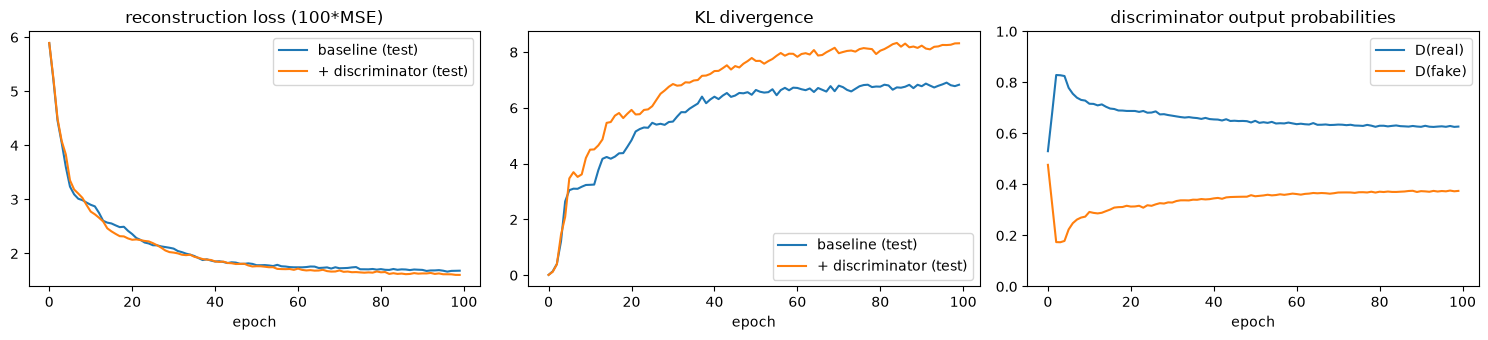

In [5]:
tb, eb = np.array(hist_base['train']), np.array(hist_base['test'])
td, ed = np.array(hist_disc['train']), np.array(hist_disc['test'])

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
axes[0].plot(eb[:, 1], label='baseline (test)'); axes[0].plot(ed[:, 1], label='+ discriminator (test)')
axes[0].set_title('reconstruction loss (100*MSE)')
axes[1].plot(eb[:, 2], label='baseline (test)'); axes[1].plot(ed[:, 2], label='+ discriminator (test)')
axes[1].set_title('KL divergence')
axes[2].plot(td[:, 5], label='D(real)'); axes[2].plot(td[:, 6], label='D(fake)')
axes[2].set_title('discriminator output probabilities'); axes[2].set_ylim(0, 1)
for ax in axes: ax.set_xlabel('epoch'); ax.legend()
plt.tight_layout(); plt.savefig('fig_training_curves.png', dpi=300); plt.show()


## Qualitative comparison: 12 samples per digit (12x10 grid)

Both models decode **the same latent vectors** (seed 0), so each cell can be compared directly.


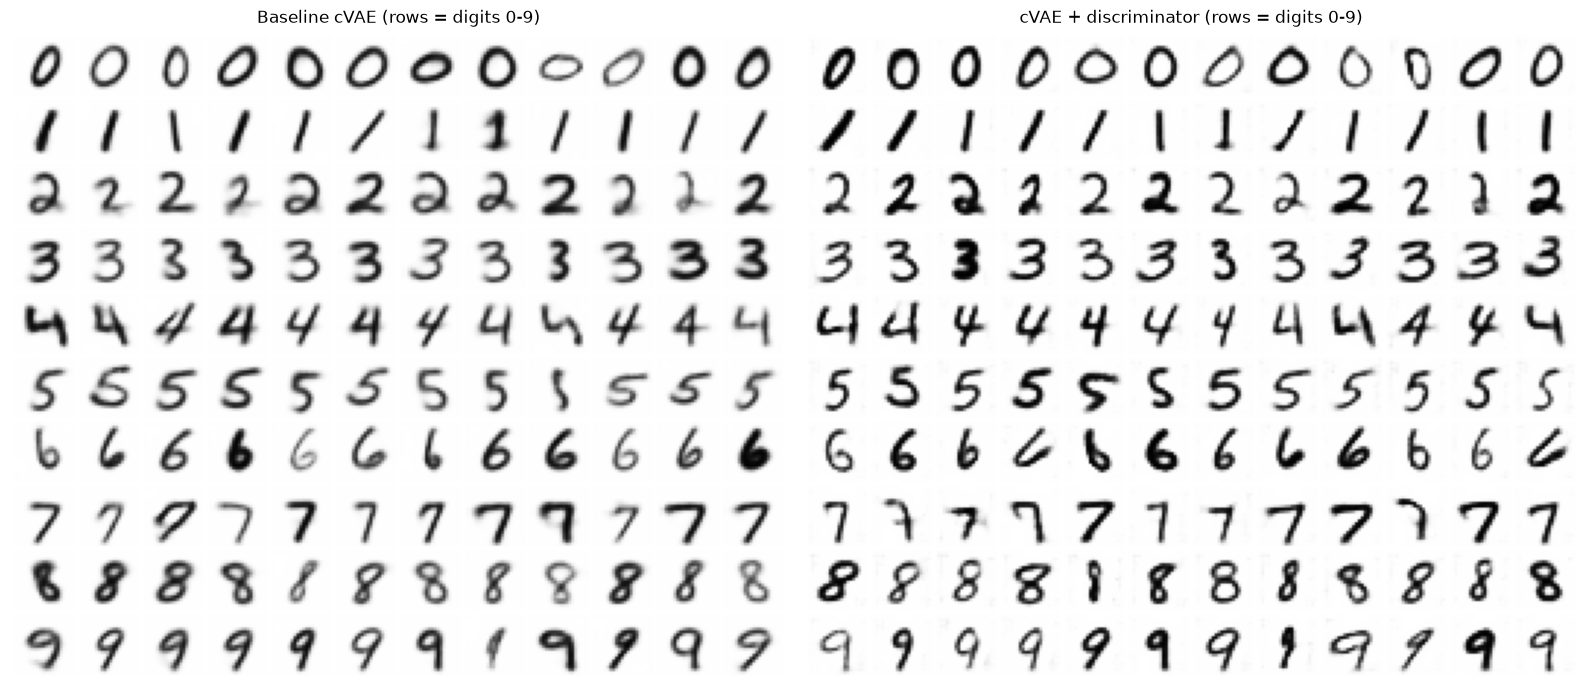

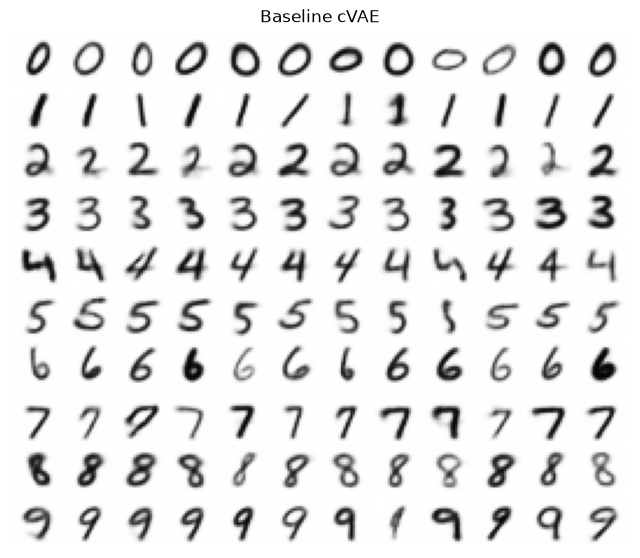

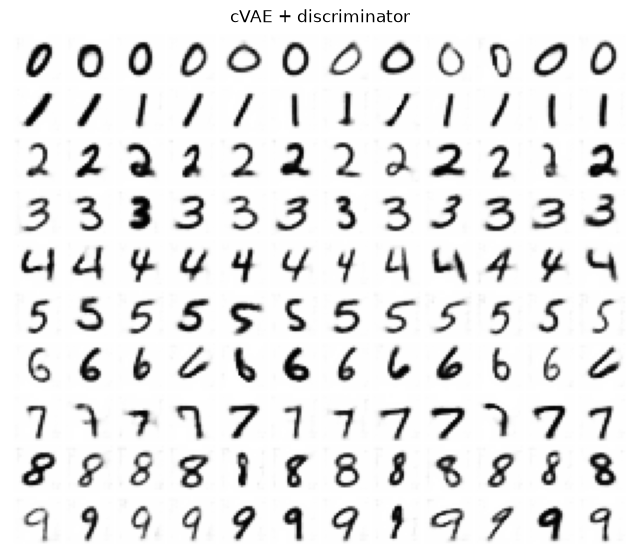

In [6]:
@torch.no_grad()
def generate(model, n_per_class, seed):
    """Conditional samples from the prior: n_per_class images for each digit 0-9."""
    model.eval()
    g = torch.Generator().manual_seed(seed)
    y = torch.arange(10).repeat_interleave(n_per_class)
    z = torch.randn(len(y), model.z_dim, generator=g)
    xs = []
    for i in range(0, len(y), 1000):
        c = F.one_hot(y[i:i+1000], 10).float().to(device)
        xs.append(model.decode(z[i:i+1000].to(device), c).cpu())
    return torch.cat(xs), y

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (name, m) in zip(axes, models.items()):
    x, _ = generate(m, 12, seed=0)
    ax.imshow(make_grid(x, nrow=12, pad_value=1).permute(1, 2, 0))
    ax.set_title(f'{name} (rows = digits 0-9)'); ax.axis('off')
plt.tight_layout(); plt.savefig('fig_sample_grids.png', dpi=300); plt.show()

# individual grids as well
for name, m in models.items():
    x, _ = generate(m, 12, seed=0)
    plt.figure(figsize=(8, 7))
    plt.imshow(make_grid(x, nrow=12, pad_value=1).permute(1, 2, 0))
    plt.title(name); plt.axis('off')
    plt.savefig('fig_grid_' + ('baseline' if 'Baseline' in name else 'disc') + '.png', dpi=300)
    plt.show()


## Reconstructions of test images

Row 1: real test images. Rows 2-3: reconstructions using the posterior mean (z = μ), so no sampling noise.


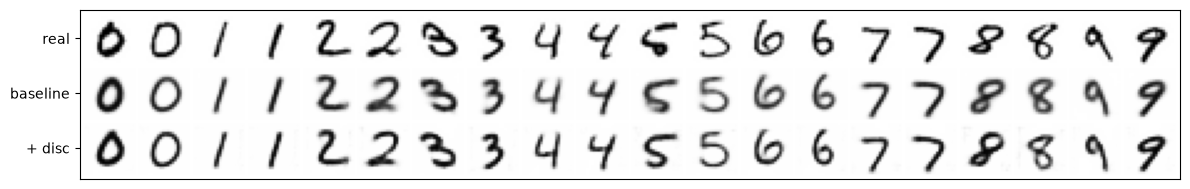

In [7]:
@torch.no_grad()
def reconstruct(model, x, y):
    model.eval()
    out = []
    for i in range(0, len(x), 1000):
        xb = x[i:i+1000].to(device); c = F.one_hot(y[i:i+1000], 10).float().to(device)
        mu, _ = model.encode(xb, c)
        out.append(model.decode(mu, c).cpu())
    return torch.cat(out)

idx = torch.cat([torch.where(test_y == k)[0][:2] for k in range(10)])
rows = [test_x[idx]] + [reconstruct(m, test_x[idx], test_y[idx]) for m in models.values()]
plt.figure(figsize=(12, 3.2))
plt.imshow(make_grid(torch.cat(rows), nrow=len(idx), pad_value=1).permute(1, 2, 0))
plt.yticks([11, 33, 55], ['real', 'baseline', '+ disc']); plt.xticks([])
plt.tight_layout(); plt.savefig('fig_reconstructions.png', dpi=300); plt.show()


## Quantitative evaluation

Metrics:
- **Sharpness**: variance of the Laplacian (higher = more edge energy = sharper). Computed in PyTorch, no OpenCV needed.
- **Recognisability**: accuracy and mean confidence of an independent digit classifier, using the conditioning label as ground truth.
- **FID (classifier features)**: Fréchet distance between generated and real test images in the 128-d penultimate layer of the digit classifier. Inception-v3 is not used because it is designed for 299x299 natural RGB images, not 20x20 digits.
- **Diversity**: mean pairwise L2 distance between samples of the same digit (guards against sharper-but-collapsed samples).
- **Reconstruction**: test-set MSE and sharpness of reconstructions.

Generated metrics use 1,000 samples per digit (10,000 per model), repeated for 3 seeds (mean ± std).


### Independent digit classifier


In [8]:
class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 32x10x10
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 64x5x5
            nn.Flatten(), nn.Linear(64 * 5 * 5, 128), nn.ReLU(),
        )
        self.head = nn.Linear(128, 10)

    def forward(self, x, return_features=False):
        f = self.features(x)
        out = self.head(f)
        return (out, f) if return_features else out

clf = DigitClassifier().to(device)
if os.path.exists('digit_classifier.pt'):
    clf.load_state_dict(torch.load('digit_classifier.pt', map_location=device))
    print('loaded digit_classifier.pt')
else:
    print('training digit classifier (runs once, then saved)')
    set_seed(0)
    loader = DataLoader(TensorDataset(train_x, train_y), batch_size=128, shuffle=True)
    opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
    for epoch in range(5):
        clf.train()
        for xb, yb in loader:
            loss = F.cross_entropy(clf(xb.to(device)), yb.to(device))
            opt.zero_grad(); loss.backward(); opt.step()
        print('epoch', epoch, 'last batch loss', round(loss.item(), 4))
    torch.save(clf.state_dict(), 'digit_classifier.pt')
clf.eval()

@torch.no_grad()
def classify(x):
    logits, feats = [], []
    for i in range(0, len(x), 1000):
        l, f = clf(x[i:i+1000].to(device), return_features=True)
        logits.append(l.cpu()); feats.append(f.cpu())
    return torch.cat(logits), torch.cat(feats)

test_logits, real_feats = classify(test_x)
print('classifier accuracy on real test images:', (test_logits.argmax(1) == test_y).float().mean().item())


training digit classifier (runs once, then saved)
epoch 0 last batch loss 0.0687
epoch 1 last batch loss 0.0197
epoch 2 last batch loss 0.0253
epoch 3 last batch loss 0.0179
epoch 4 last batch loss 0.0282
classifier accuracy on real test images: 0.9898999929428101


### Metric functions


In [9]:
LAPLACIAN = torch.tensor([[0., 1., 0.], [1., -4., 1.], [0., 1., 0.]]).view(1, 1, 3, 3)

def laplacian_variance(x):
    """Per-image variance of the Laplacian response (x: N x 1 x H x W in [0, 1])."""
    return F.conv2d(x, LAPLACIAN).flatten(1).var(dim=1)

def fid(f1, f2):
    """Frechet distance between two feature sets (rows = samples)."""
    f1, f2 = f1.double().numpy(), f2.double().numpy()
    mu1, mu2 = f1.mean(0), f2.mean(0)
    s1, s2 = np.cov(f1, rowvar=False), np.cov(f2, rowvar=False)
    w, v = np.linalg.eigh(s1)
    sqrt_s1 = (v * np.sqrt(np.clip(w, 0, None))) @ v.T
    m = sqrt_s1 @ s2 @ sqrt_s1                       # Tr sqrt(S1 S2) = Tr sqrt(S1^1/2 S2 S1^1/2)
    tr_covmean = np.sqrt(np.clip(np.linalg.eigvalsh((m + m.T) / 2), 0, None)).sum()
    return float(((mu1 - mu2) ** 2).sum() + np.trace(s1) + np.trace(s2) - 2 * tr_covmean)

def intra_class_diversity(x, y, n=200):
    """Mean pairwise L2 distance between images of the same digit."""
    out = []
    for k in range(10):
        xk = x[y == k][:n].flatten(1)
        dist = torch.cdist(xk, xk)
        out.append(dist.sum() / (len(xk) * (len(xk) - 1)))
    return torch.stack(out).mean().item()


### Compute all metrics


In [10]:
seeds, n_per_class = [0, 1, 2], 1000
cols = ['Sharpness (Lap. var.)', 'Classifier acc.', 'Classifier conf.',
        'FID (clf. features)', 'Intra-class diversity']
results, per_class_acc, sharp_dist = {}, {}, {}

# real-data reference: real train subset vs real test set
_, train_feats = classify(train_x[:10000])
p_real = test_logits.softmax(1)
results['Real test images'] = {
    cols[0]: (laplacian_variance(test_x).mean().item(), 0.0),
    cols[1]: ((p_real.argmax(1) == test_y).float().mean().item(), 0.0),
    cols[2]: (p_real.max(1).values.mean().item(), 0.0),
    cols[3]: (fid(train_feats, real_feats), 0.0),
    cols[4]: (intra_class_diversity(test_x, test_y), 0.0),
}
sharp_dist['Real test images'] = laplacian_variance(test_x)

for name, m in models.items():
    per_seed = []
    for s in seeds:
        x, y = generate(m, n_per_class, s)
        logits, feats = classify(x)
        p = logits.softmax(1)
        per_seed.append([laplacian_variance(x).mean().item(),
                         (p.argmax(1) == y).float().mean().item(),
                         p.max(1).values.mean().item(),
                         fid(feats, real_feats),
                         intra_class_diversity(x, y)])
        if s == 0:
            per_class_acc[name] = [(p.argmax(1)[y == k] == k).float().mean().item() for k in range(10)]
            sharp_dist[name] = laplacian_variance(x)
    arr = np.array(per_seed)
    results[name] = {c: (arr[:, i].mean(), arr[:, i].std()) for i, c in enumerate(cols)}

    # reconstruction quality on the full test set
    rec = reconstruct(m, test_x, test_y)
    results[name]['Test recon. MSE'] = (F.mse_loss(rec, test_x).item(), 0.0)
    results[name]['Recon. sharpness'] = (laplacian_variance(rec).mean().item(), 0.0)
print('done')


done


### Results table

Generated-sample metrics: mean ± std over 3 seeds. FID for the real row is real-train vs real-test (a lower bound for what is achievable).


In [11]:
all_cols = cols + ['Test recon. MSE', 'Recon. sharpness']
def fmt(v):
    if v is None: return '-'
    m, s = v
    return f'{m:.4f} ± {s:.4f}' if s > 0 else f'{m:.4f}'

table = pd.DataFrame({name: {c: fmt(r.get(c)) for c in all_cols} for name, r in results.items()}).T
numeric = pd.DataFrame({name: {c: r[c][0] for c in all_cols if c in r} for name, r in results.items()}).T
numeric.to_csv('results_table.csv')
table


,Sharpness (Lap. var.),Classifier acc.,Classifier conf.,FID (clf. features),Intra-class diversity,Test recon. MSE,Recon. sharpness
Real test images,0.2277,0.9899,0.9895,1.5981,5.5956,-,-
Baseline cVAE,0.1015 ± 0.0001,0.9902 ± 0.0006,0.9869 ± 0.0006,78.5806 ± 0.6138,4.4649 ± 0.0066,0.0146,0.1053
cVAE + discriminator,0.1969 ± 0.0002,0.9966 ± 0.0000,0.9943 ± 0.0005,6.8990 ± 0.0578,5.3477 ± 0.0336,0.0135,0.1918


### Sharpness distribution and per-digit recognisability (seed 0)


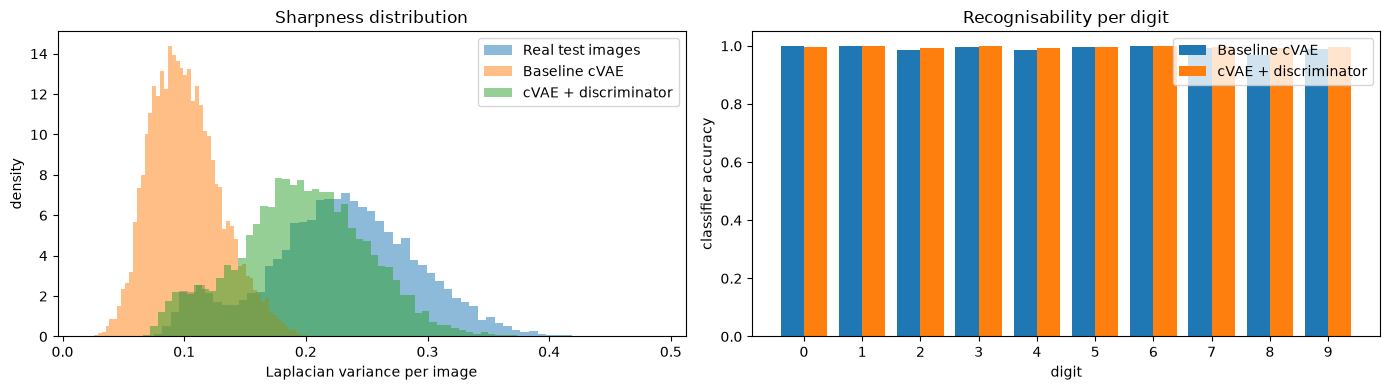

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, v in sharp_dist.items():
    axes[0].hist(v.numpy(), bins=60, alpha=0.5, density=True, label=name)
axes[0].set_xlabel('Laplacian variance per image'); axes[0].set_ylabel('density')
axes[0].set_title('Sharpness distribution'); axes[0].legend()

w = 0.4
for i, (name, acc) in enumerate(per_class_acc.items()):
    axes[1].bar(np.arange(10) + (i - 0.5) * w, acc, width=w, label=name)
axes[1].set_xticks(range(10)); axes[1].set_xlabel('digit'); axes[1].set_ylabel('classifier accuracy')
axes[1].set_ylim(0, 1.05); axes[1].set_title('Recognisability per digit'); axes[1].legend()
plt.tight_layout(); plt.savefig('fig_sharpness_and_accuracy.png', dpi=300); plt.show()
